In [1]:
import os
import sys
from pathlib import Path

root_dir = str(Path(os.getcwd()).parent)

if root_dir not in sys.path:
    sys.path.append(root_dir)

output_dir = "Outputs"
os.makedirs(output_dir, exist_ok=True)

<div style="background-color: #009dff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #7e001f">The Poisson Equation </h3>
</div>

Imports:

In [2]:
import numpy as np
from IPython.display import Video, HTML

from Solver_Classes.solpo import Poisson_Equation

---

## Steady-State Boundary Value Problems

The 2D Poisson Equation is an elliptic partial differential equation that governs physical systems in static equilibrium. It fields structural applications ranging from electrostatic potentials to steady-state heat distributions driven by a continuous load. It is defined as:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x,y)$$

Where:
* $u(x,y)$ represents the unknown equilibrium field property.
* $f(x,y)$ is a source or driving force distribution inside the domain.

**Numerical Solution:** Because this equation does not evolve in time, it is solved all at once. The `Poisson_Equation` class creates a massive 5-point stencil block Laplacian matrix using sparse Kronecker tensor products and solves the system simultaneously using a highly optimized direct sparse matrix solver (`scipy.sparse.linalg.spsolve`).

---

### Defining the Domain & Source Term:

In [3]:
#                  1. System Parameters
N = 90             # Grid resolution (N x N)
H = 2.0            # Size of the spatial domain

# 2. Source Function f(x,y) 
def source_function(x, y):
    return np.sin(np.pi * x) * np.cos(np.pi * y)

### Running the Solver & Inspecting the Static Equilibrium Dashboard:
The embedded 4-panel layout is visible below, displaying the 3D reconstructed field surface, the sparsity structure of the system operator, the source loading shape, and a flat domain contour view.

In [4]:
# Save path

dashboard_target = os.path.join(output_dir, "Poisson_Equation_Dashboard.pdf")

Assembling and solving the sparse system matrix...

Generating 4-Panel Analysis Dashboard...


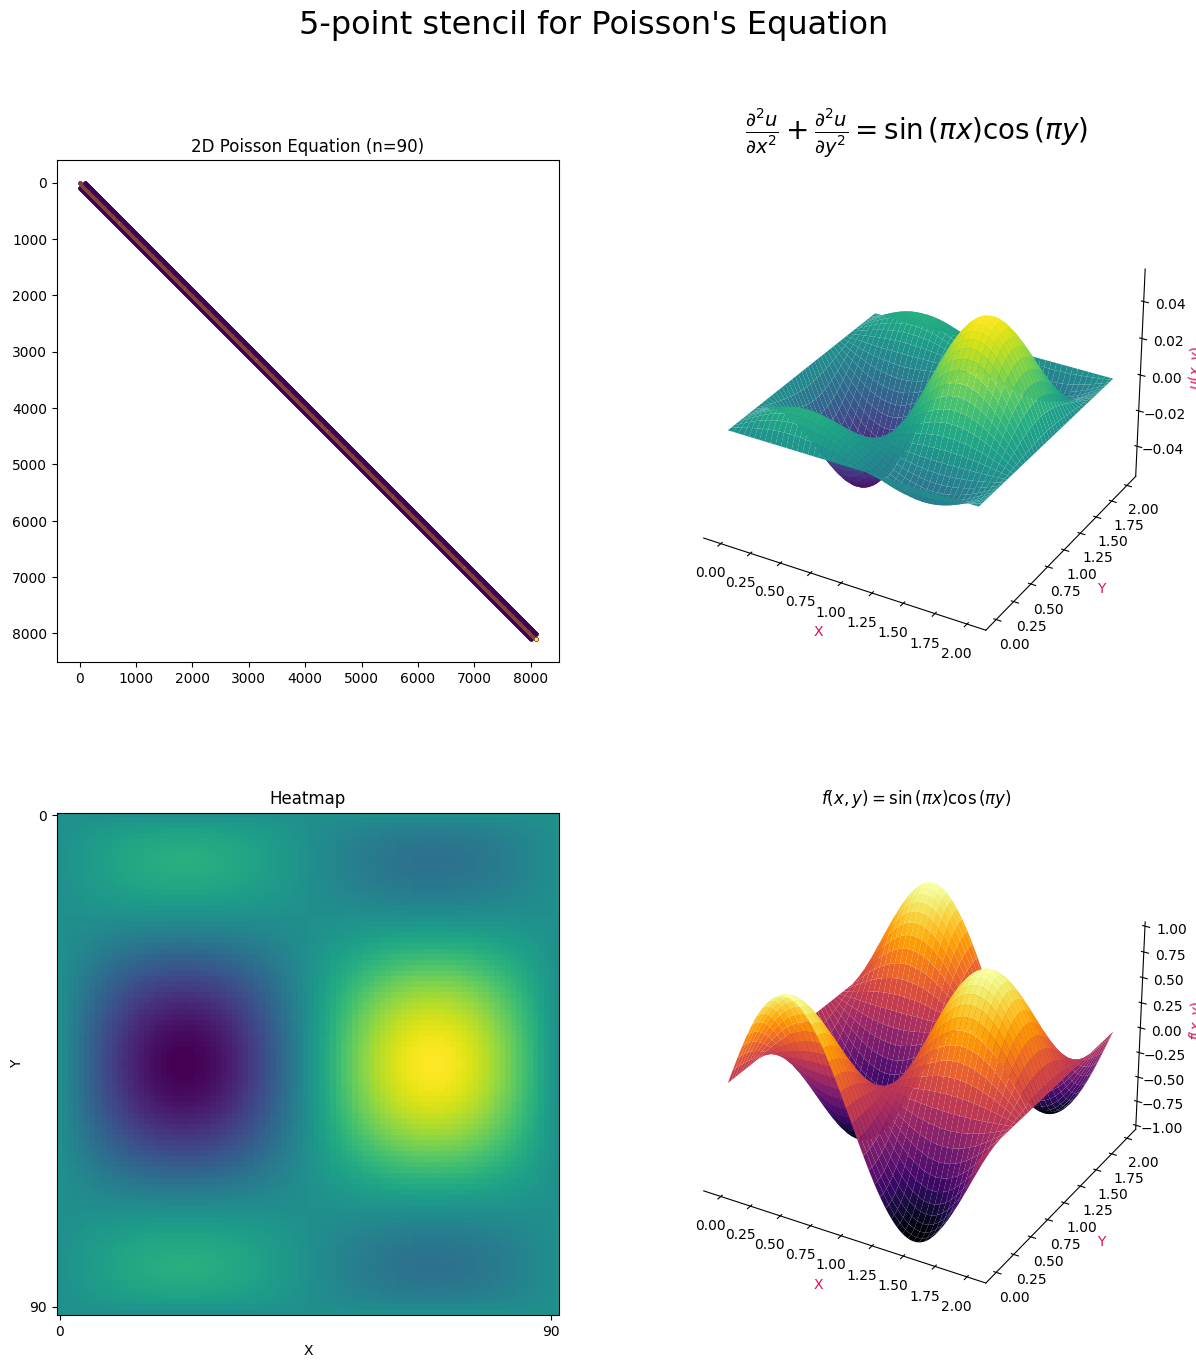

In [5]:
PE = Poisson_Equation(H=H, n=N, IC=source_function)

print("Assembling and solving the sparse system matrix...")
solution = PE.solve_Poisson_Equation()

print("\nGenerating 4-Panel Analysis Dashboard...")
PE.render_Poisson_Eqn(solution, save_path=dashboard_target)